<a href="https://colab.research.google.com/github/camilaalmeiida/wine-quality-classification/blob/main/notebooks/wine_quality_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tech Challenge - Case Classificação de Vinhos



## 1. Compreensão do Problema

O objetivo é treinar e avaliar modelos de aprendizado de máquina capazes de
prever essa classificação a partir das variáveis disponíveis.
Sobre o dataset
Fonte: wine-quality-dataset
O conjunto de dados contém variáveis como:

● Acidez fixa (fixed acidity);

● Acidez volátil (volatile acidity);

● Ácido cítrico (citric acid);

● Açúcar residual (residual sugar);

● Cloretos (chlorides);

● Dióxido de enxofre livre (free sulfur dioxide);

● Dióxido de enxofre total (total sulfur dioxide);

● Densidade (density);

● pH;

● Sulfatos (sulphates);

● Teor alcoólico (alcohol);

● Qualidade do vinho (quality).

O DESAFIO  
Desenvolver uma pipeline de análise e modelagem, contemplando as seguintes
etapas:


##2. Análise Exploratória de Dados (EDA)
Objetivo

Antes de treinar o modelo de Machine Learning, é importante compreender as características da base de dados. Nesta etapa serão analisadas a distribuição das variáveis, as correlações entre elas e a presença de possíveis outliers ou valores inconsistentes.


In [4]:
# Importando principais bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [5]:
# Importando os dados da base WineQT, delimitador do arquivo por virgula
df = pd.read_csv('WineQT.csv', sep= ",")

In [6]:
# Ler as 10 primeiras linhas
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


In [7]:
# Tipo das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [8]:
# Visualizar os ultimos 10 registros do dataset
df.tail(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1133,6.7,0.320,0.44,2.4,0.061,24.0,34.0,0.99484,3.29,0.80,11.6,7,1584
1134,7.5,0.310,0.41,2.4,0.065,34.0,60.0,0.99492,3.34,0.85,11.4,6,1586
1135,5.8,0.610,0.11,1.8,0.066,18.0,28.0,0.99483,3.55,0.66,10.9,6,1587
1136,6.3,0.550,0.15,1.8,0.077,26.0,35.0,0.99314,3.32,0.82,11.6,6,1590
1137,5.4,0.740,0.09,1.7,0.089,16.0,26.0,0.99402,3.67,0.56,11.6,6,1591
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


In [9]:
# Total de linhas e colunas
df.shape

(1143, 13)

In [10]:
# Descrição das colunas
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [11]:
# Visualizar a descrição dos dados de acordo com a variavel target
df.groupby ('quality').describe()

fixed acidity                                                     \
                count      mean       std  min   25%   50%     75%   max   
quality                                                                    
3                 6.0  8.450000  2.032486  6.7  7.15  7.45   9.700  11.6   
4                33.0  7.809091  1.685668  4.6  6.70  7.60   8.500  12.5   
5               483.0  8.161077  1.557746  5.0  7.10  7.80   8.900  15.9   
6               462.0  8.317749  1.771585  5.0  7.00  7.90   9.275  14.3   
7               143.0  8.851049  2.105187  4.9  7.40  8.70  10.100  15.6   
8                16.0  8.806250  2.089168  5.0  7.35  8.85  10.400  12.6   

        volatile acidity            ...  alcohol           Id               \
                   count      mean  ...      75%   max  count         mean   
quality                             ...                                      
3                    6.0  0.897500  ...  10.1375  10.9    6.0  1121.166667   
4                   33.0  0.700000  ...  11.0000  13.1   33.0   692.848485   
5                  483.0  0.585280  ...  10.2000  14.9  483.0   753.925466   
6                  462.0  0.504957  ...  11.4000  14.0  462.0   854.625541   
7                  143.0  0.393671  ...  12.1000  14.0  143.0   830.349650   
8                   16.0  0.410000  ...  12.8250  14.0   16.0   797.875000   

                                                             
                std    min     25%     50%      75%     max  
quality                                                      
3        496.135633  459.0  712.50  1384.0  1475.75  1505.0  
4        500.723297   41.0  170.00   703.0  1189.00  1480.0  
5        484.714472    0.0  309.50   717.0  1230.00  1597.0  
6        450.794917    3.0  467.25   894.5  1246.75  1595.0  
7        403.435969    7.0  443.00   942.0  1091.00  1584.0  
8        452.120614  267.0  451.25   543.0  1140.50  1549.0  

[6 rows x 96 columns]

In [12]:
# Verificar se há valores nulos na base
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [13]:
# Verifica a quantidade de linhas duplicadas
df.duplicated().sum()

np.int64(0)

In [14]:
# Variável de qualidade em classificação
df["Classificacao Qualidade"] = "baixa/média qualidade"
df.loc[df["quality"] >= 7, "Classificacao Qualidade"] = "alta qualidade"
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,Classificacao Qualidade
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,baixa/média qualidade
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,baixa/média qualidade
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,baixa/média qualidade
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,baixa/média qualidade
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,baixa/média qualidade
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5,baixa/média qualidade
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6,baixa/média qualidade
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7,alta qualidade
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8,alta qualidade
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10,baixa/média qualidade


In [15]:
import plotly.express as px
from plotly.subplots import make_subplots

# Gráfico 1
fig1 = px.histogram(
    df,
    x="Classificacao Qualidade",
    text_auto=True
)

# Gráfico 2
fig2 = px.histogram(
    df,
    x="quality",
    text_auto=True
)

# Criar subplots com títulos
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Classificação da Qualidade",
        "Distribuição das Notas de Qualidade"
    )
)

# Adicionar os gráficos
for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig2.data:
    fig.add_trace(trace, row=1, col=2)

# Layout
fig.update_layout(
    title="Análise da Qualidade dos Vinhos",
    title_x=0.5,      # Centraliza o título principal
    bargap=0.4,
    width=1200,
    height=500,
    showlegend=False
)

fig.show()

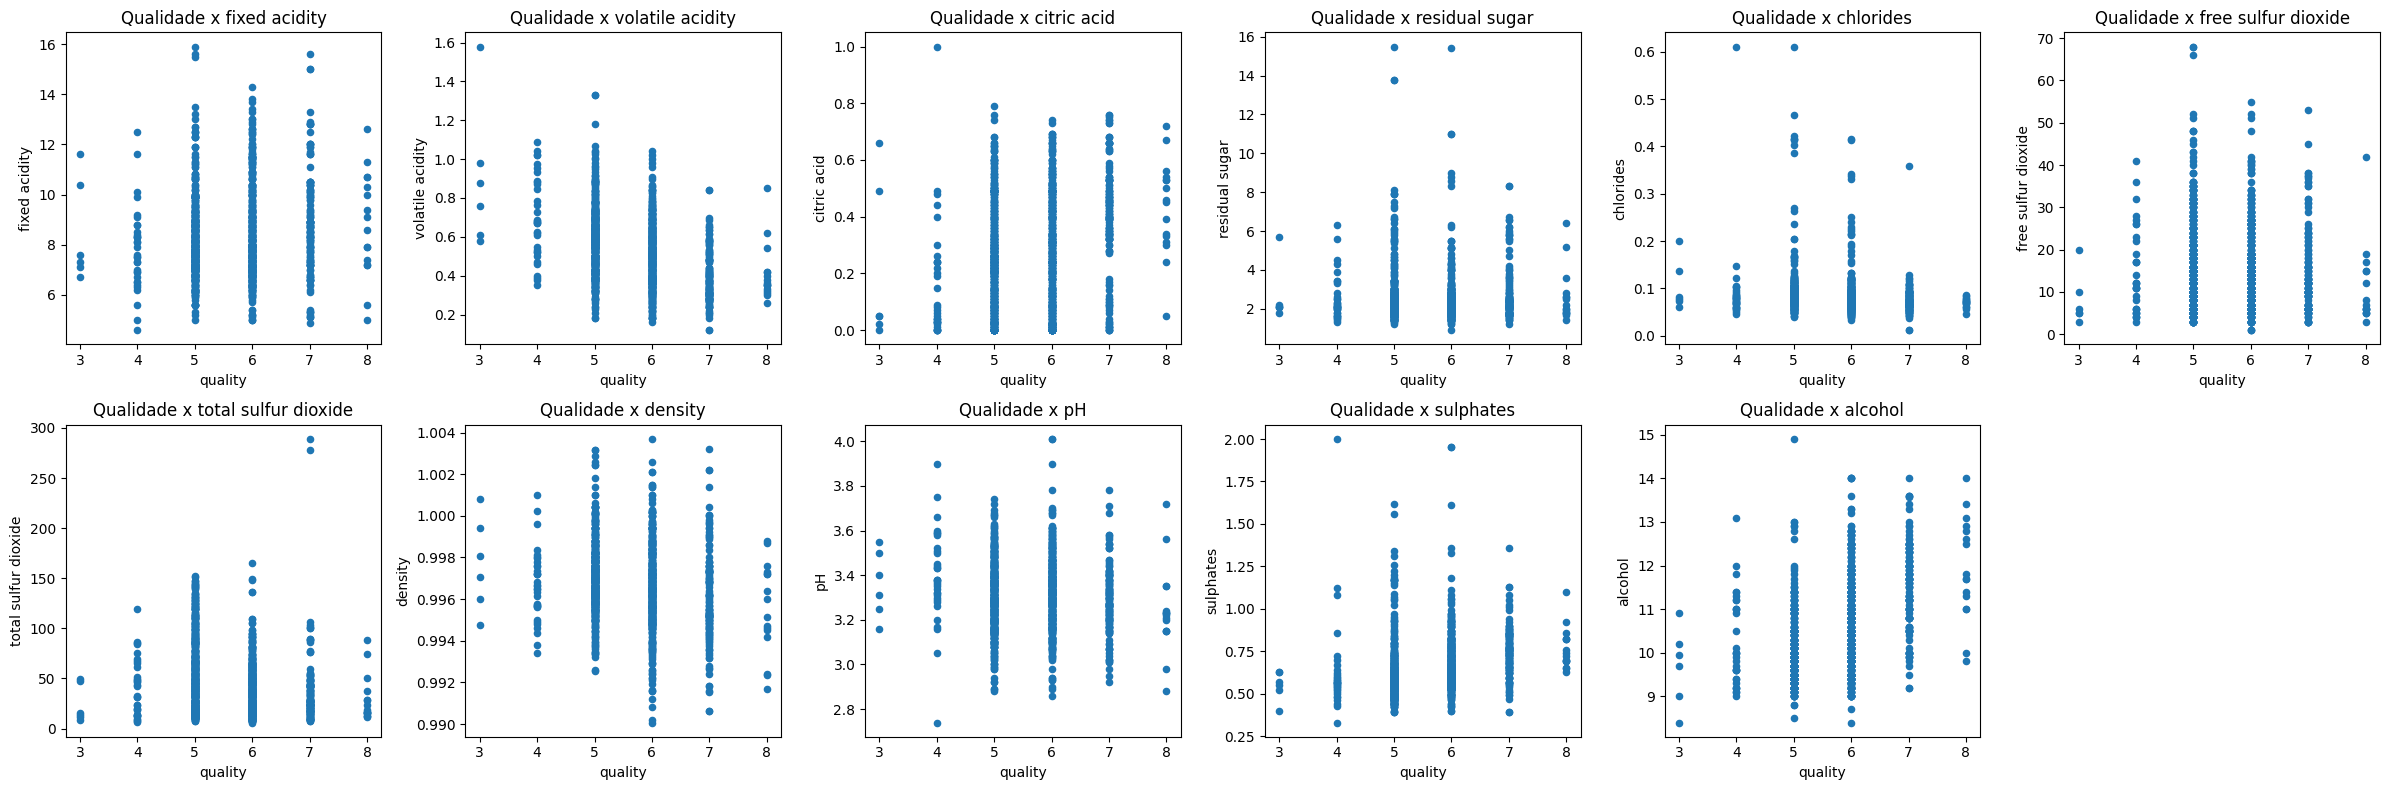

In [18]:
import matplotlib.pyplot as plt

# Criar uma figura com 2 linhas e 6 colunas
fig, ax = plt.subplots(2, 6, figsize=(24, 8))

# Transformar os eixos em uma lista
ax = ax.flatten()

# Lista das variáveis
colunas = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

# Criar um gráfico para cada variável
for i, coluna in enumerate(colunas):
    df.plot.scatter(
        x="quality",
        y=coluna,
        ax=ax[i],
        title=f"Qualidade x {coluna}"
    )

# Remover o último gráfico vazio
fig.delaxes(ax[11])

# Ajustar o espaçamento
plt.tight_layout()

# Exibir os gráficos
plt.show()

In [22]:
from sklearn.model_selection import train_test_split

# Separar dados para teste e para treino
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #stratify=y acredito q n precise, confirmar

In [25]:
list(x_test)

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

In [26]:
len(x_train)

914

In [27]:
len(x_test)

229

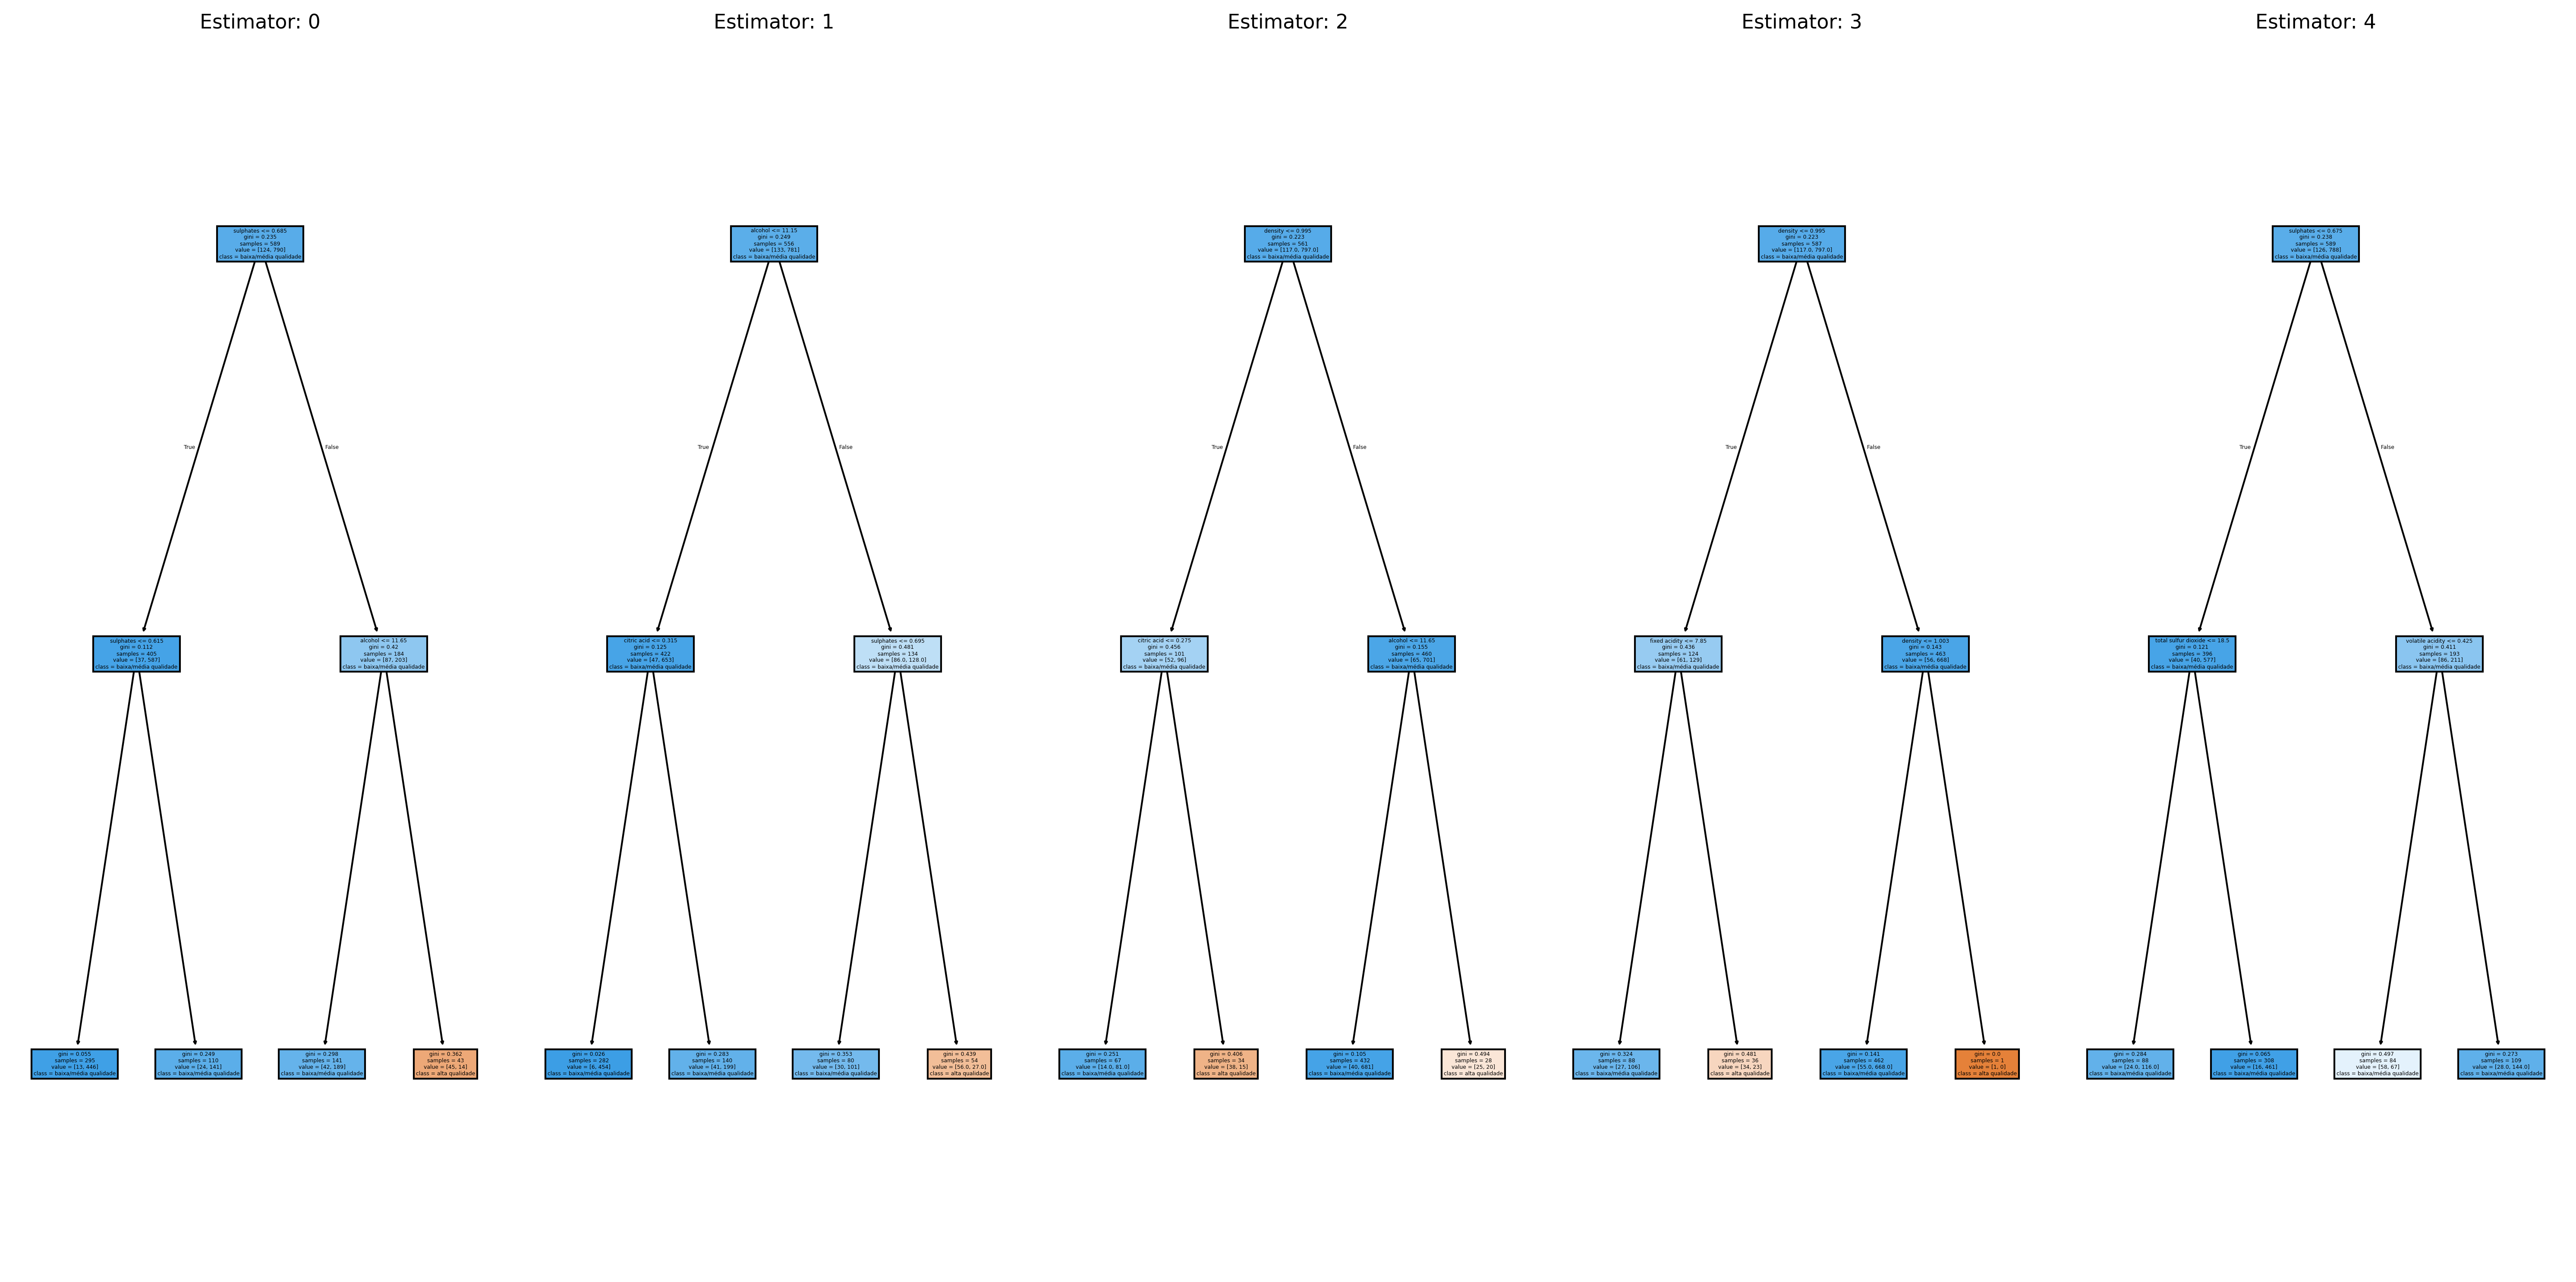

In [29]:
from sklearn.ensemble import RandomForestClassifier

  rf = RandomForestClassifier(n_estimators=5, max_depth = 2,  random_state=7)

  rf.fit(x_train, y_train)

  y_predito_random_forest = rf.predict(x_test)

  from sklearn.tree import export_graphviz


  fig, axes = plt.subplots(nrows = 1,ncols = 5,figsize = (10,2), dpi=900)
  for index in range(0, 5):
      tree.plot_tree(rf.estimators_[index],
                    feature_names = label_names,
                    class_names=class_names,
                    filled = True,
                    ax = axes[index]);

      axes[index].set_title('Estimator: ' + str(index), fontsize = 11)
  fig.savefig('rf_5trees.png')